<a href="https://colab.research.google.com/github/KoriRohini/House-Price-Prediction-Linear-Regression/blob/main/House_Price_Prediction_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from scipy.sparse import data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
data=pd.read_csv('/house-prices (1).csv')
print(data.head())

   Home   Price  SqFt  Bedrooms  Bathrooms  Offers Brick Neighborhood
0     1  114300  1790         2          2       2    No         East
1     2  114200  2030         4          2       3    No         East
2     3  114800  1740         3          2       1    No         East
3     4   94700  1980         3          2       3    No         East
4     5  119800  2130         3          3       3    No         East


In [ ]:
data.isnull()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
123,False,False,False,False,False,False,False,False
124,False,False,False,False,False,False,False,False
125,False,False,False,False,False,False,False,False
126,False,False,False,False,False,False,False,False


In [ ]:
data.isnull().sum()

,0
Home,0
Price,0
SqFt,0
Bedrooms,0
Bathrooms,0
Offers,0
Brick,0
Neighborhood,0


In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
123,False
124,False
125,False
126,False


In [ ]:
data.shape

(128, 8)

In [ ]:
data.columns

Index(['Home', 'Price', 'SqFt', 'Bedrooms', 'Bathrooms', 'Offers', 'Brick',
       'Neighborhood'],
      dtype='object')

In [ ]:
data.dtypes

,0
Home,int64
Price,int64
SqFt,int64
Bedrooms,int64
Bathrooms,int64
Offers,int64
Brick,object
Neighborhood,object


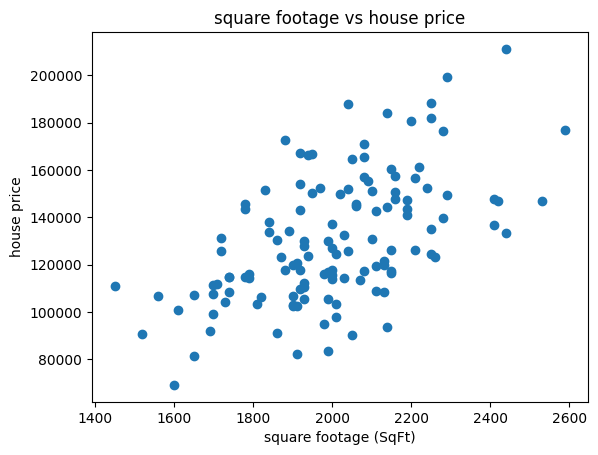

In [ ]:
plt.scatter(data["SqFt"],data["Price"])
plt.xlabel("square footage (SqFt)")
plt.ylabel("house price")
plt.title("square footage vs house price")
plt.show()


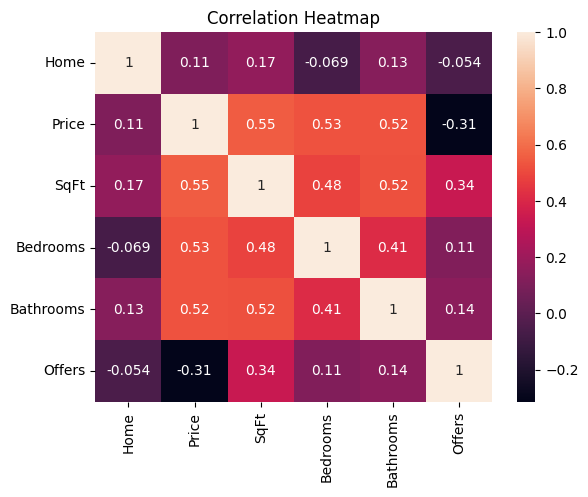

In [ ]:
correlation= data.corr(numeric_only=True)
sns.heatmap(correlation,annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

#Import feature
X=data.drop(["Price","SqFt"],axis=1)

#target variable
y=data["Price"]

#Split dataset into training and testing data
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
print("Training data:",X_train.shape)
print("Testing data:",X_test.shape)

Training data: (102, 6)
Testing data: (26, 6)


In [ ]:
print("training data:")
print(X_train.head())

training data:
    Home  Bedrooms  Bathrooms  Offers Brick Neighborhood
70    71         3          3       3   Yes         West
78    79         3          2       3    No        North
47    48         3          2       6    No        North
0      1         2          2       2    No         East
12    13         3          2       4    No        North


In [ ]:
print("training data:")
print(X_test.head())

training data:
    Home  Bedrooms  Bathrooms  Offers Brick Neighborhood
55    56         2          2       2   Yes         East
40    41         2          2       1    No         East
19    20         3          3       2   Yes         West
31    32         2          2       2   Yes        North
98    99         3          2       1    No         West


In [ ]:
from sklearn.linear_model import LinearRegression






In [ ]:
model=LinearRegression()


In [ ]:
X_train=X_train.select_dtypes(include=['number'])
X_test=X_test.select_dtypes(include=['number'])

In [ ]:
X_train=X_train.replace({'Yes':1,'No':0})

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
model.predict(X_test)

array([111244.34300512, 121133.65209633, 145236.06845173, 110307.94349733,
       137767.20229262, 115179.38558682, 151082.92669517, 106577.62581882,
       162025.68523265, 128379.47092121, 152058.34284912, 124522.46163182,
       125966.07753967, 134176.25997578, 137765.79142231, 117403.33441783,
       110503.02672812, 126666.9663002 , 113975.50823618, 101901.26696012,
       120275.28588086, 113384.61986355, 117598.41764862, 109527.61057417,
       142012.96717328, 114750.20247908])

In [ ]:
y_pred=model.predict(X_test)
print("prediction values:",y_pred[0:3])

prediction values: [111244.34300512 121133.65209633 145236.06845173]


In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("'mean Squared error:",mse)
print("R2 score",r2)


'mean Squared error: 240806155.16263837
R2 score 0.5914377189528457


In [ ]:
from sklearn.metrics import accuracy_score